# Business problem

As a marketing agency, our primary objective is to maximize the return on investment (ROI) for our clients'advertising campaigns. We have conducted 2 ad campaigns, one on Facebook and the other on AdWords, and we need to determine which platform yields etter results in term of clicks conversions and overall cost-effectiveness. By identifying the most effective platform, we can allocate our resources more efficiently and optimize our advertising strategies to deliver better outcomes for our clients.

# Research Question

Which ad platform is more effective in term of conversions, clicks, and overall cost-effectiveness

# Import Libraries

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as st
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import coint
import warnings
warnings.filterwarnings('ignore')

# Data Description

The dataset comprises a collection of data comparing the performance of two separate ad campaigns conducted throughout the year 2019. Specifically, the data covers a Facebook Ad campaign and an Adwords Ad campaign. For each day of the year 2019, there is a corresponding row in the dataset resulting in a total of 3365 lines of campaign data to analyze. The dataset includes various performance metrics for each ad campaign, providing insights into their effectiveness and efficiency over time.

Key features included in the dataset are as follows:
- Date: The date corresponding to each row of campaign data, ranging from January 1st,2019 to December 31st,2019.
- Ad Views: The number of times the ad was viewed.
- Ad Clicks: The number of clicks recieved on the ad
- Ad Coversions: The number of conversions resulting from the ad
- Cost per Ad: The cost associated with running the Facebook ad campaign.
- Click-Through Rate (CTR): The ratio of clicks to views, indicating the effectiveness of the ad in generating clicks.
- Conversion Rate: The ratio of conversions to clicks, reflecting the effectiveness of the ad in driving desired actions.
- Cost per Click (CPC): The average cost incurred per click on the ad.

In [8]:
df = pd.read_csv("A_B_testing_dataset.csv")
df.head()

,date_of_campaign,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ad_campaign,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,adword_ctr,adword_conversion_rate,adword_cost_per_click
0,2021-12-22,FACEBOOK AD,3172,62,14,141,1.95,22.58,2.27,ADWORD AD,5754,64,9,177,1.11,14.06,2.77
1,2021-12-24,FACEBOOK AD,3211,38,9,186,1.18,23.68,4.89,ADWORD AD,4954,73,6,54,1.47,8.22,0.74
2,2021-12-25,FACEBOOK AD,1936,53,15,66,2.74,28.30,1.25,ADWORD AD,4702,38,9,187,0.81,23.68,4.92
3,2021-12-25,FACEBOOK AD,1194,45,9,71,3.77,20.00,1.58,ADWORD AD,3718,58,3,161,1.56,5.17,2.78
4,2021-12-26,FACEBOOK AD,2479,44,12,174,1.77,27.27,3.95,ADWORD AD,5562,63,4,162,1.13,6.35,2.57


In [9]:
df.shape

(1000, 17)

In [10]:
df.dtypes

date_of_campaign             object
facebook_ad_campaign         object
facebook_ad_views             int64
facebook_ad_clicks            int64
facebook_ad_conversions       int64
facebook_cost_per_ad          int64
facebook_ctr                float64
facebook_conversion_rate    float64
facebook_cost_per_click     float64
adword_ad_campaign           object
adword_ad_views               int64
adword_ad_clicks              int64
adword_ad_conversions         int64
adword_cost_per_ad            int64
adword_ctr                  float64
adword_conversion_rate      float64
adword_cost_per_click       float64
dtype: object

In [11]:
df['date_of_campaign'] = pd.to_datetime(df['date_of_campaign'])

In [12]:
df.dtypes

date_of_campaign            datetime64[ns]
facebook_ad_campaign                object
facebook_ad_views                    int64
facebook_ad_clicks                   int64
facebook_ad_conversions              int64
facebook_cost_per_ad                 int64
facebook_ctr                       float64
facebook_conversion_rate           float64
facebook_cost_per_click            float64
adword_ad_campaign                  object
adword_ad_views                      int64
adword_ad_clicks                     int64
adword_ad_conversions                int64
adword_cost_per_ad                   int64
adword_ctr                         float64
adword_conversion_rate             float64
adword_cost_per_click              float64
dtype: object

In [13]:
df.describe()

,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,adword_ctr,adword_conversion_rate,adword_cost_per_click
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2152.031000,44.196000,11.975000,156.610000,2.28316,32.696080,4.310500,4771.438000,60.128000,5.933000,124.741000,1.280950,10.807510,2.265540
std,661.982166,16.833328,4.298471,54.918904,1.20670,20.570796,2.751582,598.647684,17.047822,2.011606,43.809053,0.402492,5.205133,1.101846
min,1050.000000,15.000000,5.000000,60.000000,0.49000,6.850000,0.960000,3715.000000,31.000000,3.000000,50.000000,0.540000,3.370000,0.580000
25%,1600.250000,30.000000,8.000000,110.000000,1.36750,18.052500,2.337500,4258.250000,45.000000,4.000000,86.000000,0.940000,6.970000,1.470000
50%,2123.500000,44.500000,12.000000,156.000000,2.07000,27.120000,3.600000,4808.500000,60.000000,6.000000,124.000000,1.260000,9.720000,2.030000
75%,2706.250000,58.000000,16.000000,205.000000,2.92250,41.880000,5.610000,5300.750000,75.000000,8.000000,163.000000,1.570000,13.485000,2.802500
max,3320.000000,73.000000,19.000000,250.000000,6.86000,118.750000,16.530000,5754.000000,89.000000,9.000000,200.000000,2.370000,29.030000,6.190000


# Comparing Campaigns performance

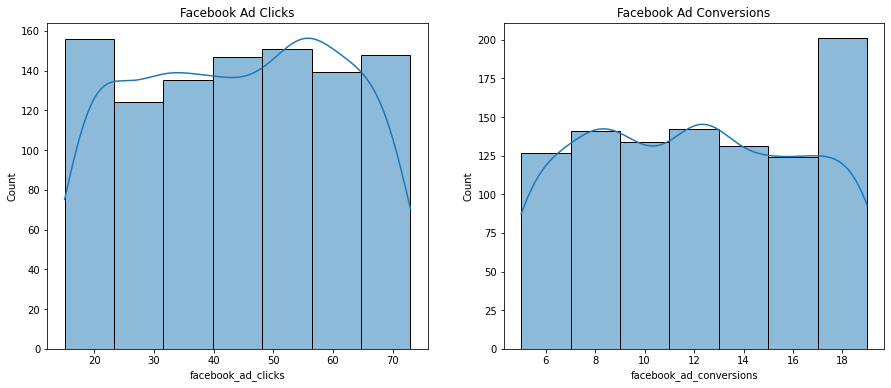

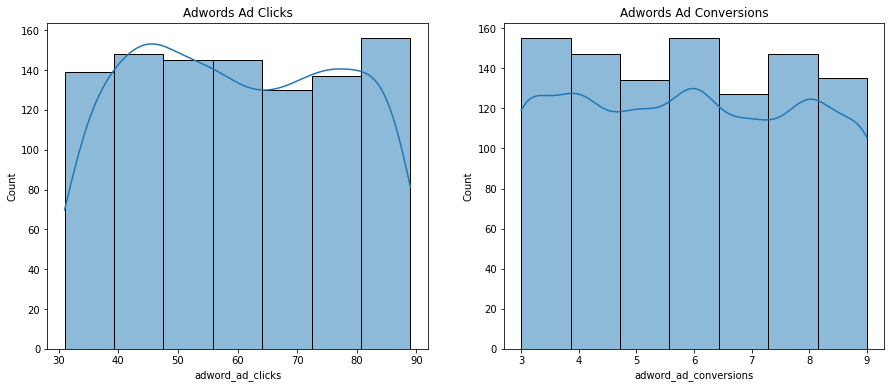

In [19]:
# distribution of the clicks and conversions
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.title('Facebook Ad Clicks')
sns.histplot(df['facebook_ad_clicks'], bins = 7, edgecolor = 'k', kde = True)
plt.subplot(1,2,2)
plt.title('Facebook Ad Conversions')
sns.histplot(df['facebook_ad_conversions'], bins = 7, edgecolor = 'k', kde = True)
plt.show()

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.title('Adwords Ad Clicks')
sns.histplot(df['adword_ad_clicks'], bins = 7, edgecolor = 'k', kde = True)
plt.subplot(1,2,2)
plt.title('Adwords Ad Conversions')
sns.histplot(df['adword_ad_conversions'], bins = 7, edgecolor = 'k', kde = True)
plt.show()

All the histogram are showing somewhat symmetrical shape. This symmetrical shape suggests that the numer of clicks and conversions is relatively evenly distributed. In other words there are not many clicks or conversions that are outliers on either the high or low end.

## How frequently do we observe days with high numbers of conversions compared to days with low numbers of conversion?

In [23]:
# creating function to calculate the category for the conversion
def create_conversion_category(conversion_col):
    category = []
    for conversion in df[conversion_col]:
        if conversion < 6:
            category.append('less than 6')
        elif 6 <= conversion < 11:
            category.append('6-10')
        elif 11 <= conversion < 16:
            category.append('11-15')
        else:
            category.append('more than 15')
    return category

# applying function of different campaign's conversions
df['facebook conversion category'] = create_conversion_category('facebook_ad_conversions')
df['adwords conversion category'] = create_conversion_category('adword_ad_conversions')

In [25]:
df.head()

,date_of_campaign,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ad_campaign,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,adword_ctr,adword_conversion_rate,adword_cost_per_click,facebook conversion category,adwords conversion category
0,2021-12-22,FACEBOOK AD,3172,62,14,141,1.95,22.58,2.27,ADWORD AD,5754,64,9,177,1.11,14.06,2.77,11-15,6-10
1,2021-12-24,FACEBOOK AD,3211,38,9,186,1.18,23.68,4.89,ADWORD AD,4954,73,6,54,1.47,8.22,0.74,6-10,6-10
2,2021-12-25,FACEBOOK AD,1936,53,15,66,2.74,28.30,1.25,ADWORD AD,4702,38,9,187,0.81,23.68,4.92,11-15,6-10
3,2021-12-25,FACEBOOK AD,1194,45,9,71,3.77,20.00,1.58,ADWORD AD,3718,58,3,161,1.56,5.17,2.78,6-10,less than 6
4,2021-12-26,FACEBOOK AD,2479,44,12,174,1.77,27.27,3.95,ADWORD AD,5562,63,4,162,1.13,6.35,2.57,11-15,less than 6


In [26]:
df[['facebook_ad_conversions', 'facebook conversion category', 'adword_ad_conversions', 'adwords conversion category']]

,facebook_ad_conversions,facebook conversion category,adword_ad_conversions,adwords conversion category
0,14,11-15,9,6-10
1,9,6-10,6,6-10
2,15,11-15,9,6-10
3,9,6-10,3,less than 6
4,12,11-15,4,less than 6
...,...,...,...,...
995,8,6-10,3,less than 6
996,13,11-15,5,less than 6
997,19,more than 15,4,less than 6
998,19,more than 15,6,6-10


In [39]:
facebook = pd.DataFrame(df['facebook conversion category'].value_counts()).reset_index().rename(columns = {'index':'Category','facebook conversion category':'Count'})
facebook

,Category,Count
0,11-15,341
1,6-10,337
2,more than 15,257
3,less than 6,65


In [45]:
adwords = pd.DataFrame(df['adwords conversion category']).value_counts().reset_index().rename(columns={'adwords conversion category':'Category',0:'Count'})
adwords

,Category,Count
0,6-10,564
1,less than 6,436


In [50]:
category_df = pd.merge(facebook, adwords, on='Category', how='outer').fillna(0)
category_df

,Category,Count_x,Count_y
0,11-15,341,0.0
1,6-10,337,564.0
2,more than 15,257,0.0
3,less than 6,65,436.0


In [51]:
category_df = category_df.iloc[[3,1,0,2]]
category_df

,Category,Count_x,Count_y
3,less than 6,65,436.0
1,6-10,337,564.0
0,11-15,341,0.0
2,more than 15,257,0.0


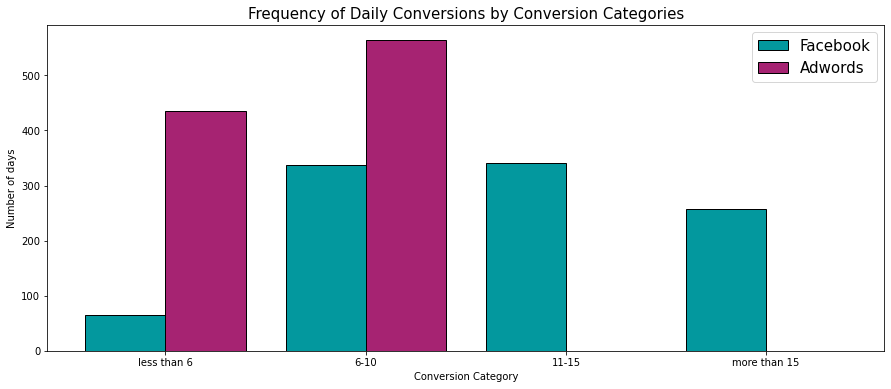

In [70]:
x_axis = np.arange(len(category_df))
plt.figure(figsize=(15,6))
plt.bar(x_axis - 0.2, category_df['Count_x'], 0.4, label = 'Facebook', color = '#03989E', linewidth = 1, edgecolor = 'k')
plt.bar(x_axis + 0.2, category_df['Count_y'], 0.4, label = 'Adwords', color = '#A62372', linewidth = 1, edgecolor = 'k')

plt.xticks(x_axis, category_df['Category'])
plt.xlabel('Conversion Category')
plt.ylabel('Number of days')
plt.title('Frequency of Daily Conversions by Conversion Categories', fontsize=15)
plt.legend(fontsize=15)

plt.show()

- The data suggests Facebook had more frequent higher conversion days than Adwords, which either had very low conversion rates (less than 6) or moderate ones (6-10)
- There is a significant variance in the number of high-conversion days between two different campaigns.
- The absence of any days with conversions between 10-15 and more than 15 in Adwords indicates a need to review what strategies were changed or what external factors could have influenced these numer.

Do more clicks on the ad really lead to more sales?

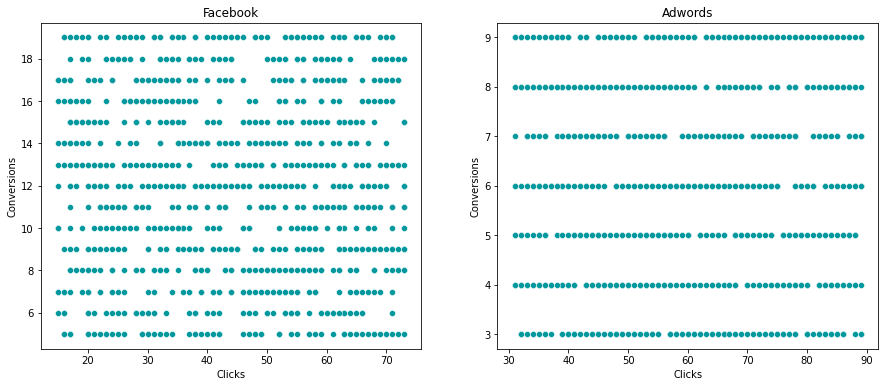

In [58]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.title('Facebook')
sns.scatterplot(x = df['facebook_ad_clicks'], y = df['facebook_ad_conversions'], color = '#03989E')
plt.xlabel('Clicks')
plt.ylabel('Conversions')
plt.subplot(1,2,2)
plt.title('Adwords')
sns.scatterplot(x = df['adword_ad_clicks'], y = df['adword_ad_conversions'], color = '#03989E')
plt.xlabel('Clicks')
plt.ylabel('Conversions')
plt.show()

In [59]:
facebook_corr = df[['facebook_ad_conversions','facebook_ad_clicks']].corr()
facebook_corr

,facebook_ad_conversions,facebook_ad_clicks
facebook_ad_conversions,1.000000,-0.005009
facebook_ad_clicks,-0.005009,1.000000


In [60]:
adword_corr = df[['adword_ad_conversions','adword_ad_clicks']].corr()
adword_corr

,adword_ad_conversions,adword_ad_clicks
adword_ad_conversions,1.000000,0.004162
adword_ad_clicks,0.004162,1.000000


In [68]:
print('Correlation Coeff \n--------------')
print('Facebook :', round(facebook_corr.values[0,1],2))
print('Adwords :', round(adword_corr.values[0,1],3))

Correlation Coeff 
--------------
Facebook : -0.01
Adwords : 0.004


# Hypothesis Testing

### Hypothesis: Advertising on Facebook will result in a greater number of conversions compared to advertising on Adwords

- Null Hypothesis (H0): There is no difference in the number of conversions between Facebook and Adwords, or the number of conversions from AdWords is greater than or equal to those from Facebook.

H0: u_Facebook <= u_AdWords

- Alternate Hypothesis (H1): The number of conversions from Facebook is freater than the number of conversions from AdWords.

H1: u_Facebook > u_AdWords

In [77]:
print('Mean Conversion \n----------------')
print('Facebook :', round(df['facebook_ad_conversions'].mean(),2))
print('AdWords : ', round(df['adword_ad_conversions'].mean(),2))

t_stats, p_value = st.ttest_ind(a=df['facebook_ad_conversions'], b=df['adword_ad_conversions'], equal_var=True)
print('\nT statistic: ', t_stats, '\np-value: ', p_value)

#Comparing the pvalue with the significance of 5% or 0.05
if p_value < 0.05:
    print('\np-value is less than significance value, Reject the null Hypothesis')
else:
    print('\np-value is greater than significance value, Accept the null Hypothesis')

Mean Conversion 
----------------
Facebook : 11.97
AdWords :  5.93

T statistic:  40.25906231407936 
p-value:  5.194664900442006e-260

p-value is less than significance value, Reject the null Hypothesis


- The mean number of conversion from Facebook ads (11.97) is substantially higher than the mean number of conversions from AdWords ads (5.93). This suggests that on average, Facebook advertising is more effective in generating conversions compared to AdWords advertising.
- The T statistic (40.26) is a measure of the difference between the means of the two groups relative to the variation within the groups. A larger T statistic indicates a greater difference between the means of the two groups.
- The P-value (5.195e-26) is extremely small, indicating strong evidence against the null hypothesis.
- The results strongly support the alternate hypothesis, indicating that the number of conversions from Facebook advertising is indeed greater than the number of conversions from AdWords advertising.
- Facebook advertising appears to be a more effective channel for generating conversions compared to AdWords advertising based on the sample data analyzed.
- Given the significant difference in conversion rates between Facebook and AdWords, consider reallocating resources towards Facebook advertising efforts. This could involve increasing ad spend, expanding targeting efforts, or experimenting with different ad formats to capitalize on the platform's effectiveness in driving conversions.

# Regression Analysis

What will happen when i do go with the Facebook ad? How many facebook ad conversions can i expect given a certain number of facebook ad clicks?

In [82]:
# independent variable
X = df[['facebook_ad_clicks']]
# dependent variable
Y = df[['facebook_ad_conversions']]

#initializing and fitting Linear Regression model
reg_model = LinearRegression()
reg_model.fit(X, Y)
prediction = reg_model.predict(X)

# Model evaluation
r2 = r2_score(Y, prediction)
mse = mean_squared_error(Y, prediction)
print('Accuracy (R2 Score): ', round(r2,2), '%')
print('Mean squared error: ', round(mse,2))

Accuracy (R2 Score):  0.0 %
Mean squared error:  18.46


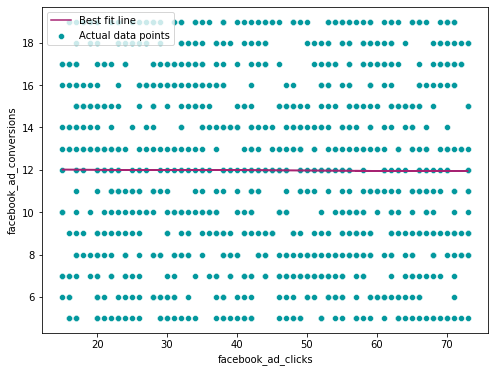

In [86]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['facebook_ad_clicks'], y=df['facebook_ad_conversions'], color='#03989E', label='Actual data points')
plt.plot(df['facebook_ad_clicks'], prediction, color='#A62372', label='Best fit line')
plt.legend()
plt.show()

In [87]:
print(f'For {50} Clicks, Expected Conversion : {round(reg_model.predict([[50]])[0][0],2)}')
print(f'For {80} Clicks, Expected Conversion : {round(reg_model.predict([[80]])[0][0],2)}')

For 50 Clicks, Expected Conversion : 11.97
For 80 Clicks, Expected Conversion : 11.93


- The model has a reasonable good predictive power, with an R2 score of 76.35%. This suggests that it can effectively predict Facebook ad conversions based on the number of Facebook ad clicks.
- With the insights provided by the Linear Regression model, businesses can make informed decisions about resource allocation, buget planning, and campaign optimization.
- For instance, knowing the expected number of Facebook ad conversions ased on a certain number of Facebook ad clicks can help in setting realistic campaign goals, optimizing ad spend, and assessing the ROI of Facebook advertising efforts.

# Analyzing Facebook Campaign metrics over time

In [89]:
df.head()

,date_of_campaign,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ad_campaign,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,adword_ctr,adword_conversion_rate,adword_cost_per_click,facebook conversion category,adwords conversion category
0,2021-12-22,FACEBOOK AD,3172,62,14,141,1.95,22.58,2.27,ADWORD AD,5754,64,9,177,1.11,14.06,2.77,11-15,6-10
1,2021-12-24,FACEBOOK AD,3211,38,9,186,1.18,23.68,4.89,ADWORD AD,4954,73,6,54,1.47,8.22,0.74,6-10,6-10
2,2021-12-25,FACEBOOK AD,1936,53,15,66,2.74,28.30,1.25,ADWORD AD,4702,38,9,187,0.81,23.68,4.92,11-15,6-10
3,2021-12-25,FACEBOOK AD,1194,45,9,71,3.77,20.00,1.58,ADWORD AD,3718,58,3,161,1.56,5.17,2.78,6-10,less than 6
4,2021-12-26,FACEBOOK AD,2479,44,12,174,1.77,27.27,3.95,ADWORD AD,5562,63,4,162,1.13,6.35,2.57,11-15,less than 6


In [100]:
#cleaning data (removing unwanted symbols from the columns and converting them to numerical columns)
df['facebook_ctr'] = df['facebook_ctr'].apply(lambda x : float(x))
df['facebook_conversion_rate'] = df['facebook_conversion_rate'].apply(lambda x : float(x))
df['facebook_cost_per_click'] = df['facebook_cost_per_click'].apply(lambda x : float(x))
df['facebook_cost_per_ad'] = df['facebook_cost_per_ad'].apply(lambda x : float(x))

In [102]:
# filtering for facebook campaign
df_filter = df[['date_of_campaign','facebook_ad_views','facebook_ad_clicks','facebook_ad_conversions',
                'facebook_cost_per_ad', 'facebook_ctr', 'facebook_conversion_rate', 'facebook_cost_per_click']]
df_filter.head()

,date_of_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click
0,2021-12-22,3172,62,14,141.0,1.95,22.58,2.27
1,2021-12-24,3211,38,9,186.0,1.18,23.68,4.89
2,2021-12-25,1936,53,15,66.0,2.74,28.30,1.25
3,2021-12-25,1194,45,9,71.0,3.77,20.00,1.58
4,2021-12-26,2479,44,12,174.0,1.77,27.27,3.95


At what times of the month or days of the week do we observe the conversions?

In [104]:
# Extracting month and week day from the data column
df_filter['month'] = df_filter['date_of_campaign'].dt.month
df_filter['week'] = df_filter['date_of_campaign'].dt.weekday

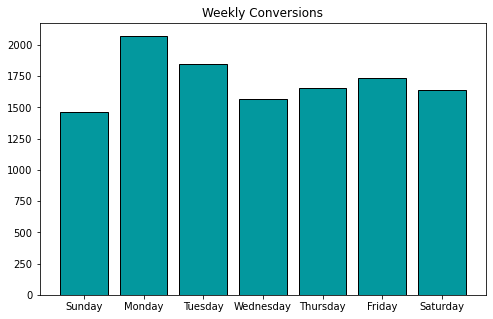

In [114]:
plt.figure(figsize=(8,5))
plt.title('Weekly Conversions')
weekly_conversion = df_filter.groupby('week')[['facebook_ad_conversions']].sum()
week_names = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
plt.bar(week_names, weekly_conversion['facebook_ad_conversions'], color='#03989E', edgecolor='k')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

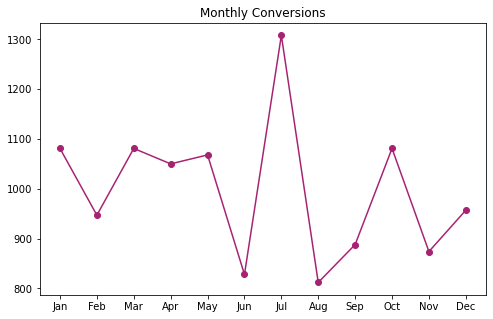

In [117]:
plt.figure(figsize=(8,5))
plt.title('Monthly Conversions')
monthly_conversion = df_filter.groupby('month')[['facebook_ad_conversions']].sum()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.plot(month_names, monthly_conversion['facebook_ad_conversions'], marker='o', color='#A62372')
plt.show

- Across the weekdays over a year, the total number of conversions remains relatively consistent, indicating a consistent level of engagement throughout the week. However, Monday and Tuesdays consistently exhibit the highest conversion rates compared to other days, suggesting that the beginning of the workweek sees heightened user engagement or responsiveness to marketing efforts.
- Examining the monthly trend in conversions reveals an overall upward trajectory indicating a general increase in conversions over time. However, certain months stand out with variations in conversion rates. February, April May, June, August and November experience a decline in conversions compared to neighoring months. These periods of decreased conversion rates could be influenced by factors such as seasonal fluctuations, changes in consumer behavior, or adjustments in marketing strategies.

# How does the Cost Per Conversion (CPC) trend over time?

Cost Per Conversion (CPC): This metric is used to evaluate the cost effectiveness and profitability of an online advertising campaign. This metric helps marketers understand how much they are spending to obtain each conversion, allowing them to optimize their spending and targeting strategies effectively.

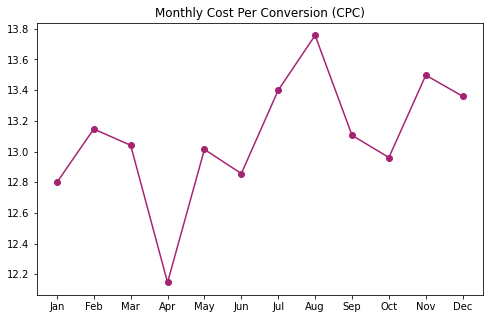

In [121]:
plt.figure(figsize=(8,5))
plt.title('Monthly Cost Per Conversion (CPC)')
monthly_df = df_filter.groupby('month')[['facebook_ad_conversions','facebook_cost_per_ad']].sum()
monthly_df['Cost Per Conversion'] = monthly_df['facebook_cost_per_ad'] / monthly_df['facebook_ad_conversions']
plt.plot(month_names, monthly_df['Cost Per Conversion'], marker='o', color='#A62372')
plt.show()

- The CPC trend over the 12-month period shows some fluctuations but overall maintains a relatively stable range.
- May and November have the lowest CPC values, indicating potentially more cost-effective advertising or higher conversion rates during these periods.
- February has the highest CPC value, suggesting that advertising costs may be relatively higher during this month compared to others.
- Lower CPC values in certain months (e.g., May and November) could indicate periods of higher advertising effectiveness or more favorable market conditions.
- Consider allocating more advertising budget to months with historically lower CPC values (e.g., May and November) to maximize ROI.

# Is there a long-term equilibrium relationship between advertising spend and conversion rates that suggests a stable proportional impact of budget changes on conversions over time?

In [127]:
score_coint, p_value, _ = coint(df['facebook_cost_per_ad'], df['facebook_ad_conversions'])
print('Cointegration test score: ', score_coint)
print('P-value: ', p_value)
if p_value < 0.05:
    print('\np-value is less than significance value, Reject the null Hypothesis')
else:
    print('\np-value is greater than significance value, Accept the null Hypothesis')

Cointegration test score:  -31.71894313242047
P-value:  0.0

p-value is less than significance value, Reject the null Hypothesis


- Since the p-value is significantly lower than the chosen significance level, we reject the null hypothesis. This indicates that there is a long-term equilibrium relationship between advertising spend (cost) and conversions.
- Businesses can use this understanding of the stable relationship between cost and conversions to optimize their advertising strategies. By investing in campaigns that demonstrate a strong return on investment (ROI) and adjusting spending based on performance, companies can maximize conversions while minimizing costs.